## 1. Import Required Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [2]:
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "Data" / "Processed_Data"

df_medidata = pd.read_parquet(PROCESSED_DIR / "df_medidata.parquet")

print(f"Loaded data shape: {df_medidata.shape}")
print(f"Data ready for analysis")

Loaded data shape: (1178407, 20)
Data ready for analysis


## NORMALIZED EFFICIENCY METRICS

Raw totals (total discharges, total payment gaps) are influenced by hospital size.
Normalized metrics allow fair comparison across hospitals of different sizes.

New metrics created:
- `discharges_per_bed` = Tot_Dschrgs / BED_CNT  → ***How busy is a hospital relative to its size?***
- `payment_gap_per_discharge` = Payment_Gap / Tot_Dschrgs  → ***How much does Medicare underpay per individual patient case?***
- `Payment_Ratio` = Avg_Mdcr_Pymt_Amt / Avg_Submtd_Cvrd_Chrg  → ***What fraction of the billed charge does Medicare actually pay?***

## 2. Calculate Normalized Efficiency Metrics

In [3]:
# Payment Gap: absolute dollar difference between billed charge and Medicare payment
if 'Payment_Gap' not in df_medidata.columns:
    df_medidata['Payment_Gap'] = df_medidata['Avg_Submtd_Cvrd_Chrg'] - df_medidata['Avg_Mdcr_Pymt_Amt']

# Payment Ratio: proportion of billed charge actually reimbursed by Medicare
if 'Payment_Ratio' not in df_medidata.columns:
    df_medidata['Payment_Ratio'] = df_medidata['Avg_Mdcr_Pymt_Amt'] / df_medidata['Avg_Submtd_Cvrd_Chrg']

# Discharges per bed: utilization intensity
df_medidata['discharges_per_bed'] = np.where(
    df_medidata['BED_CNT'] > 0,
    df_medidata['Tot_Dschrgs'] / df_medidata['BED_CNT'],
    np.nan
)

# Payment gap per discharge
df_medidata['payment_gap_per_discharge'] = np.where(
    df_medidata['Tot_Dschrgs'] > 0,
    df_medidata['Payment_Gap'] / df_medidata['Tot_Dschrgs'],
    np.nan
)

print('New columns added:')
print(df_medidata[['Payment_Gap','Payment_Ratio','discharges_per_bed','payment_gap_per_discharge']].describe().round(2))

New columns added:
       Payment_Gap  Payment_Ratio  discharges_per_bed  \
count   1178407.00     1178407.00          1178407.00   
mean      61524.74           0.23                0.14   
std       83310.29           0.15                0.43   
min     -107877.07           0.00                0.00   
25%       21582.59           0.14                0.04   
50%       38709.58           0.20                0.07   
75%       71531.49           0.27                0.13   
max     9667453.74           8.15               97.33   

       payment_gap_per_discharge  
count                 1178407.00  
mean                     3079.15  
std                      5057.88  
min                     -9535.18  
25%                       728.51  
50%                      1635.85  
75%                      3525.32  
max                    478421.39  


In [4]:
print("Negative Payment_Gap:", (df_medidata['Payment_Gap'] < 0).sum())
print("Negative gap_per_discharge:", (df_medidata['payment_gap_per_discharge'] < 0).sum())
print("Payment_Ratio > 1:", (df_medidata['Payment_Ratio'] > 1).sum())

Negative Payment_Gap: 1539
Negative gap_per_discharge: 1539
Payment_Ratio > 1: 1539


## 3. Analyze Efficiency Metrics by Hospital Ownership Type

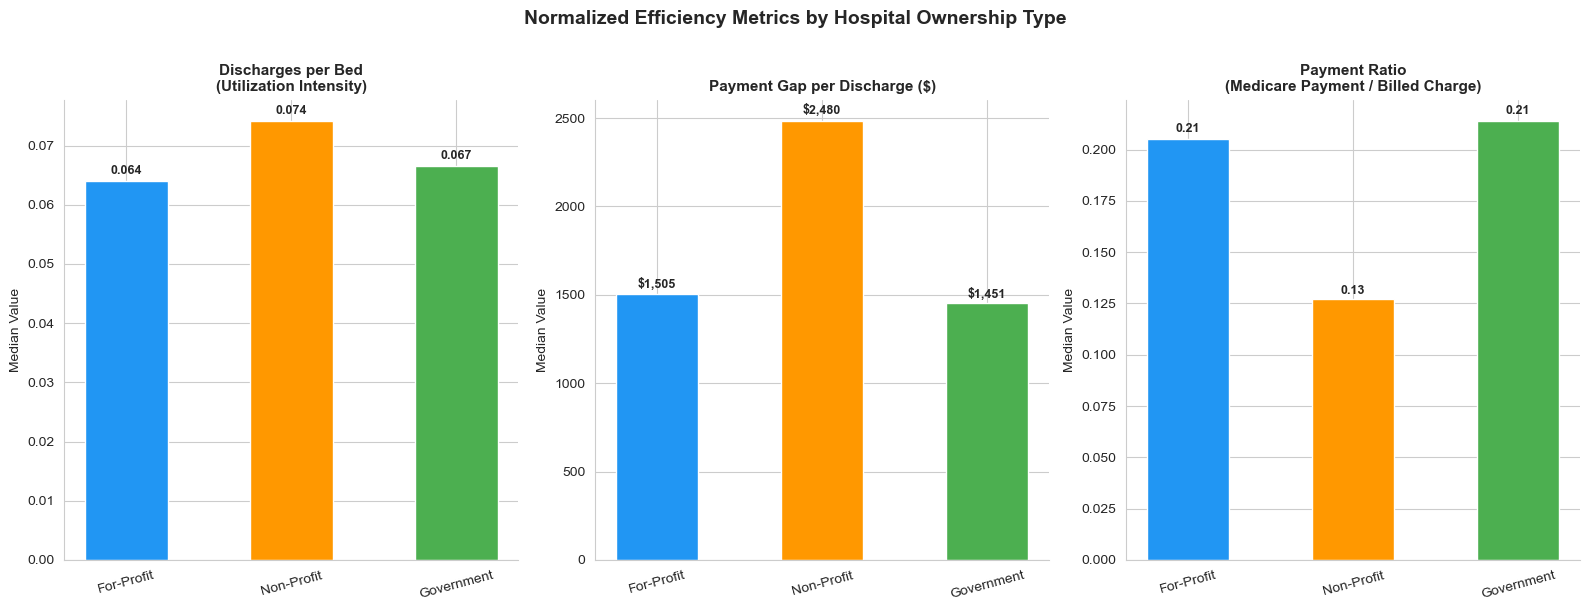


Median values by ownership:
                Payment_Ratio  payment_gap_per_discharge  discharges_per_bed
Ownership_Type                                                              
For-Profit             0.2052                  1505.3646              0.0641
Government             0.2137                  1451.1582              0.0666
Non-Profit             0.1271                  2480.4907              0.0741


In [5]:
ownership_df = df_medidata[df_medidata['Ownership_Type'].isin(['For-Profit', 'Non-Profit', 'Government'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Normalized Efficiency Metrics by Hospital Ownership Type', fontsize=14, fontweight='bold', y=1.01)

palette = {'For-Profit': '#2196F3', 'Non-Profit': '#FF9800', 'Government': '#4CAF50'}
metrics = [
    ('discharges_per_bed',       'Discharges per Bed\n(Utilization Intensity)',           '{:.3f}'),
    ('payment_gap_per_discharge','Payment Gap per Discharge ($)',                         '${:,.0f}'),
    ('Payment_Ratio',            'Payment Ratio\n(Medicare Payment / Billed Charge)',    '{:.2f}'),
]

for ax, (col, title, fmt) in zip(axes, metrics):
    means = ownership_df.groupby('Ownership_Type')[col].median().reindex(['For-Profit','Non-Profit','Government'])
    bars  = ax.bar(means.index, means.values, color=[palette[o] for o in means.index], edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Median Value')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                fmt.format(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nMedian values by ownership:')
print(ownership_df.groupby('Ownership_Type')[['Payment_Ratio','payment_gap_per_discharge','discharges_per_bed']]
      .median().round(4))

### Insights: Normalized Efficiency Metrics by Hospital Ownership Type

**Chart 1 — Discharges per Bed (Utilization Intensity)**
- Non-Profit hospitals treat more patients per available bed (0.074) compared to For-Profit (0.064) and Government (0.067) hospitals
- The differences across ownership types are small, suggesting bed utilization intensity is broadly consistent
- For-Profit hospitals operate with the most spare capacity per bed

**Chart 2 — Payment Gap per Discharge ($)**
- Non-Profit hospitals carry the largest payment gap per patient at $2,480 — nearly double Government hospitals ($1,451)
- Government hospitals show the smallest gap per discharge

**Chart 3 — Payment Ratio (Medicare Payment / Billed Charge)**
- Non-Profit hospitals recover 13 cents per dollar billed vs 21 cents for For-Profit and Government hospitals

In [6]:
ownership_order = ['For-Profit', 'Non-Profit', 'Government']
test_metrics    = ['Payment_Ratio', 'payment_gap_per_discharge', 'discharges_per_bed']

def eta_squared_kruskal(groups):
    """Calculate eta-squared effect size for Kruskal-Wallis test."""
    all_vals  = np.concatenate(groups)
    n         = len(all_vals)
    k         = len(groups)
    H, _      = kruskal(*groups)
    eta2      = (H - k + 1) / (n - k)
    return max(eta2, 0)

def effect_label(eta2):
    if eta2 >= 0.14: return 'Large'
    elif eta2 >= 0.06: return 'Medium'
    elif eta2 >= 0.01: return 'Small'
    else: return 'Negligible'

print('=' * 70)
print('KRUSKAL-WALLIS TEST — OWNERSHIP TYPE (For-Profit vs Non-Profit vs Government)')
print('=' * 70)

for metric in test_metrics:
    groups = [
        ownership_df[ownership_df['Ownership_Type'] == o][metric].dropna().values
        for o in ownership_order
    ]
    H_stat, p_val = kruskal(*groups)
    eta2          = eta_squared_kruskal(groups)
    sig           = '*** Significant' if p_val < 0.05 else 'Not significant'
    print(f'\nMetric: {metric}')
    print(f'  H-statistic : {H_stat:,.2f}')
    print(f'  p-value     : {p_val:.4e}  →  {sig}')
    print(f'  Eta-squared : {eta2:.4f}  →  Effect size: {effect_label(eta2)}')

KRUSKAL-WALLIS TEST — OWNERSHIP TYPE (For-Profit vs Non-Profit vs Government)

Metric: Payment_Ratio
  H-statistic : 101,587.14
  p-value     : 0.0000e+00  →  *** Significant
  Eta-squared : 0.0862  →  Effect size: Medium

Metric: payment_gap_per_discharge
  H-statistic : 30,364.94
  p-value     : 0.0000e+00  →  *** Significant
  Eta-squared : 0.0258  →  Effect size: Small

Metric: discharges_per_bed
  H-statistic : 3,228.01
  p-value     : 0.0000e+00  →  *** Significant
  Eta-squared : 0.0027  →  Effect size: Negligible



### Inferential Analysis: Payment Differences by Hospital Ownership Type

**Test Used: Kruskal-Wallis (all three groups) + Pairwise Mann-Whitney U**

**Overall Explainability by Ownership Type**

| Metric | η² | Effect | Meaning |
|---|---|---|---|
| Payment_Ratio | 0.0862 | Medium | Ownership explains 8.6% of payment ratio variation |
| Payment_Gap_per_Discharge | 0.0258 | Small | Ownership explains 2.6% of gap per patient |
| Discharges_per_Bed | 0.0027 | Negligible | Ownership explains 0.3% of bed utilization |

---

**Pairwise Differences — Payment Ratio**

| Pair | Medians | Cohen's d | Effect |
|---|---|---|---|
| For-Profit vs Non-Profit | 0.205 vs 0.127 | 0.55 | Medium |
| For-Profit vs Government | 0.205 vs 0.214 | -0.05 | Negligible |
| Non-Profit vs Government | 0.127 vs 0.214 | -0.53 | Medium |

- Non-Profit hospitals recover significantly less per dollar billed (0.13) 
  compared to For-Profit (0.21) and Government (0.21)
- For-Profit and Government are statistically different but practically 
  identical — less than 1 cent difference per dollar billed
- Non-Profit hospitals carry the largest payment gap per discharge ($2,480) —
  nearly double Government ($1,451) and higher than For-Profit ($1,505)


## 4. Analyze Efficiency Metrics by Geographic Classification (RUCA)

In [7]:
ruca_mapping = df_medidata[['Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc']].drop_duplicates().sort_values('Rndrng_Prvdr_RUCA')
ruca_counts = df_medidata['Rndrng_Prvdr_RUCA'].value_counts().sort_index()
ruca_summary = ruca_mapping.set_index('Rndrng_Prvdr_RUCA').join(ruca_counts.rename('Count'))
ruca_summary = ruca_summary.reset_index().sort_values('Count', ascending=False)

print("RUCA Code to Description Mapping with Value Counts:")
print(ruca_summary.to_string(index=False))

RUCA Code to Description Mapping with Value Counts:
 Rndrng_Prvdr_RUCA                                                                               Rndrng_Prvdr_RUCA_Desc   Count
               1.0                  Metropolitan area core: primary flow within an urbanized area of 50,000 and greater 1008770
               4.0                     Micropolitan area core: primary flow within an urban cluster of 10,000 to 49,999   95407
               1.1                          Secondary flow 30% to <50% to a larger urbanized area of 50,000 and greater   18512
               2.0 Metropolitan area high commuting: primary flow 30% or more to a urbanized area of 50,000 and greater   17446
               7.0                              Small town core: primary flow within an urban cluster of 2,500 to 9,999   16640
              99.0                                                                                              Unknown    5739
               5.0         Micropolitan high commuti

In [8]:
def map_ruca_group(ruca_val):
    if pd.isna(ruca_val) or ruca_val == 99.0:
        return 'Unknown'
    elif ruca_val in [1.0, 1.1, 2.0, 2.1, 3.0]:
        return 'Metropolitan'
    elif ruca_val in [4.0, 4.1, 5.0, 6.0]:
        return 'Micropolitan'
    elif ruca_val in [7.0, 7.1, 7.2, 8.0, 8.2, 9.0]:
        return 'Small Town'
    else:
        return 'Rural'

df_medidata['RUCA_Group'] = df_medidata['Rndrng_Prvdr_RUCA'].apply(map_ruca_group)
print(df_medidata['RUCA_Group'].value_counts())

RUCA_Group
Metropolitan    1045269
Micropolitan     104963
Small Town        18606
Unknown            5739
Rural              3830
Name: count, dtype: int64


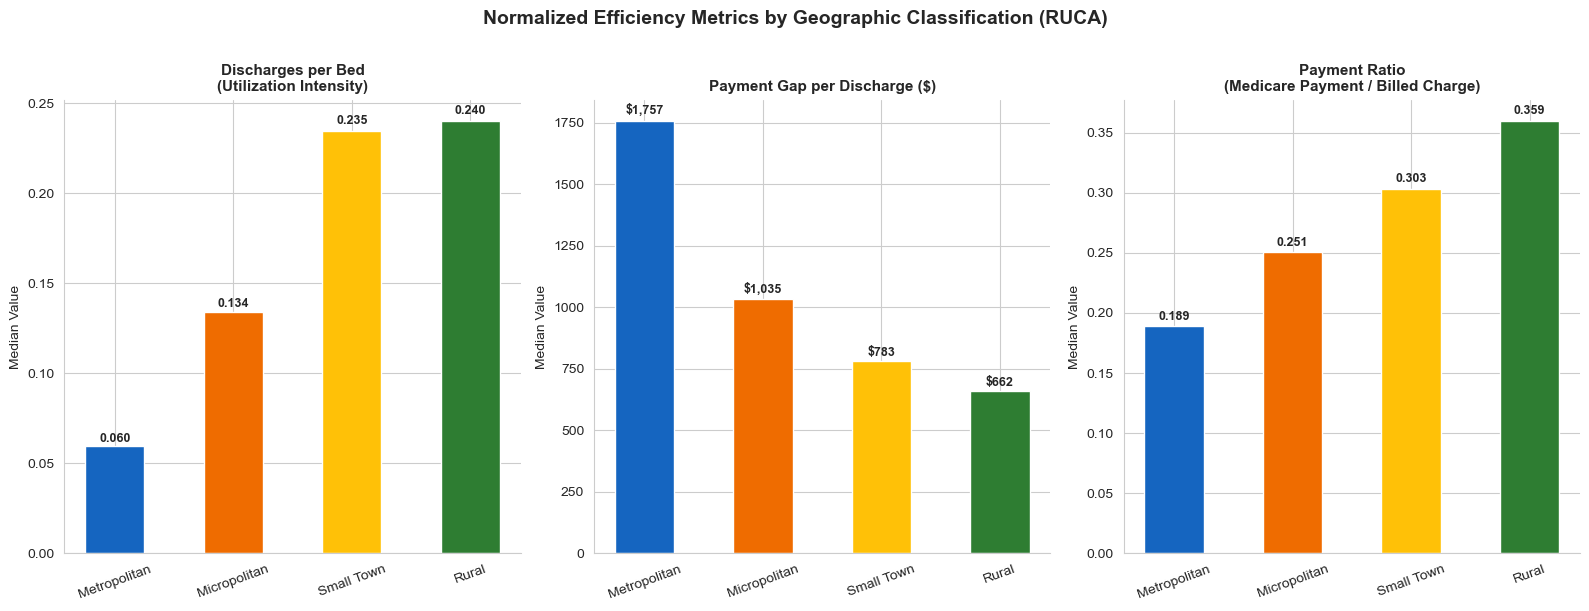


Median values by RUCA group:
              Payment_Ratio  payment_gap_per_discharge  discharges_per_bed
RUCA_Group                                                                
Metropolitan         0.1894                  1757.0809              0.0598
Micropolitan         0.2510                  1034.7392              0.1339
Small Town           0.3033                   782.6799              0.2346
Rural                0.3595                   661.7992              0.2400


In [9]:
geo_df = df_medidata[df_medidata['RUCA_Group'] != 'Unknown'].copy()
ruca_order = ['Metropolitan', 'Micropolitan', 'Small Town', 'Rural']
geo_palette = {
    'Metropolitan': '#1565C0',
    'Micropolitan': '#EF6C00',
    'Small Town': '#FFC107',   
    'Rural': '#2E7D32'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Normalized Efficiency Metrics by Geographic Classification (RUCA)', fontsize=14, fontweight='bold', y=1.01)

metrics = [
    ('discharges_per_bed',       'Discharges per Bed\n(Utilization Intensity)',         '{:.3f}'),
    ('payment_gap_per_discharge','Payment Gap per Discharge ($)',                       '${:,.0f}'),
    ('Payment_Ratio',            'Payment Ratio\n(Medicare Payment / Billed Charge)',  '{:.3f}'),
]

for ax, (col, title, fmt) in zip(axes, metrics):
    means = geo_df.groupby('RUCA_Group')[col].median().reindex(ruca_order)
    bars  = ax.bar(means.index, means.values, color=[geo_palette[g] for g in means.index], edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Median Value')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                fmt.format(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nMedian values by RUCA group:')
print(geo_df.groupby('RUCA_Group')[['Payment_Ratio','payment_gap_per_discharge','discharges_per_bed']]
      .median().reindex(ruca_order).round(4))

### Insights: Normalized Efficiency Metrics by Geographic Classification (RUCA)

**Chart 1 — Discharges per Bed (Utilization Intensity)**
- Rural (0.240) and Small Town (0.235) hospitals treat nearly 4x more patients per available bed compared to Metropolitan hospitals (0.060)
- Metropolitan hospitals operate with significantly more breathing room

**Chart 2 — Payment Gap per Discharge ($)**
- Metropolitan hospitals carry the largest payment gap per patient at $1,757 — more than double that of Rural hospitals ($662)
- The gap shrinks consistently as hospitals become less urban

**Chart 3 — Payment Ratio (Medicare Payment / Billed Charge)**
- Rural hospitals recover 35.9 cents per dollar billed — nearly double the 18.9 cents recovered by Metropolitan hospitals
- The recovery rate improves consistently from Metropolitan to Rural, forming a clear geographic gradient

##  INFERENTIAL TESTS: GEOGRAPHY (RUCA GROUP)


In [10]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import numpy as np

# ── Helper functions (defined once, outside all loops) ────────────────────────

def eta_squared_kruskal(groups):
    """How much of total variation is explained by group membership."""
    all_vals = np.concatenate(groups)
    n        = len(all_vals)
    k        = len(groups)
    H, _     = kruskal(*groups)
    eta2     = (H - k + 1) / (n - k)
    return max(eta2, 0)

def effect_label_eta(eta2):
    if eta2 >= 0.14:   return 'Large'
    elif eta2 >= 0.06: return 'Medium'
    elif eta2 >= 0.01: return 'Small'
    else:              return 'Negligible'

def cohens_d(x, y):
    """Practical size of difference between two groups."""
    x, y   = np.asarray(x), np.asarray(y)
    nx, ny = x.size, y.size
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    pooled = np.sqrt(((nx - 1)*sx**2 + (ny - 1)*sy**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled if pooled > 0 else 0

def effect_label_d(d):
    d = abs(d)
    if d >= 0.8:   return 'Large'
    elif d >= 0.5: return 'Medium'
    elif d >= 0.2: return 'Small'
    else:          return 'Negligible'

# ── Configuration ─────────────────────────────────────────────────────────────

ruca_order   = ['Metropolitan', 'Micropolitan', 'Small Town', 'Rural']
test_metrics = ['Payment_Ratio', 'payment_gap_per_discharge', 'discharges_per_bed']

# Exclude Unknown from geographic comparisons
geo_df = df_medidata[df_medidata['RUCA_Group'] != 'Unknown'].copy()

# Bonferroni correction: 4 groups = 6 pairs → adjusted alpha = 0.05/6
pairs          = list(combinations(ruca_order, 2))
adjusted_alpha = 0.05 / len(pairs)

# ── PART 1: Kruskal-Wallis — overall explainability by geography ──────────────

print('=' * 70)
print('KRUSKAL-WALLIS TEST — GEOGRAPHIC GROUP')
print('How much does geography explain variation in each metric?')
print('=' * 70)

for metric in test_metrics:
    groups        = [geo_df[geo_df['RUCA_Group'] == g][metric].dropna().values for g in ruca_order]
    H_stat, p_val = kruskal(*groups)
    eta2          = eta_squared_kruskal(groups)
    sig           = '*** Significant' if p_val < 0.05 else 'Not significant'

    print(f'\nMetric : {metric}')
    print(f'  H-statistic : {H_stat:,.2f}')
    print(f'  p-value     : {p_val:.4e}  →  {sig}')
    print(f'  Eta-squared : {eta2:.4f}  →  Effect size: {effect_label_eta(eta2)}')
    print(f'  Interpretation: Geography explains {eta2*100:.1f}% of variation in {metric}')

# ── PART 2: Pairwise Mann-Whitney U — which specific pairs differ ─────────────

metric_labels = {
    'Payment_Ratio': 'Payment Ratio (Medicare Payment / Billed Charge)',
    'payment_gap_per_discharge': 'Payment Gap per Discharge ($)',
    'discharges_per_bed': 'Discharges per Bed (Utilization Intensity)'
}

for metric in test_metrics:
    print(f'\n{"=" * 70}')
    print(f'PAIRWISE MANN-WHITNEY U — {metric_labels[metric].upper()}')
    print(f'Bonferroni corrected alpha: {adjusted_alpha:.4f}  (0.05 / {len(pairs)} pairs)')
    print('=' * 70)

    for g1_name, g2_name in pairs:
        g1            = geo_df[geo_df['RUCA_Group'] == g1_name][metric].dropna().values
        g2            = geo_df[geo_df['RUCA_Group'] == g2_name][metric].dropna().values
        u_stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
        d             = cohens_d(g1, g2)
        sig           = '*** Significant' if p_val < adjusted_alpha else 'Not significant'

        print(f'\n  {g1_name} vs {g2_name}')
        print(f'    U-statistic : {u_stat:,.0f}')
        print(f'    p-value     : {p_val:.4e}  →  {sig}')
        print(f'    Cohen\'s d   : {d:.4f}  →  Effect size: {effect_label_d(d)}')
        print(f'    Median {g1_name:<25}: {np.median(g1):,.2f}')
        print(f'    Median {g2_name:<25}: {np.median(g2):,.2f}')

KRUSKAL-WALLIS TEST — GEOGRAPHIC GROUP
How much does geography explain variation in each metric?

Metric : Payment_Ratio
  H-statistic : 45,128.20
  p-value     : 0.0000e+00  →  *** Significant
  Eta-squared : 0.0385  →  Effect size: Small
  Interpretation: Geography explains 3.8% of variation in Payment_Ratio

Metric : payment_gap_per_discharge
  H-statistic : 28,594.50
  p-value     : 0.0000e+00  →  *** Significant
  Eta-squared : 0.0244  →  Effect size: Small
  Interpretation: Geography explains 2.4% of variation in payment_gap_per_discharge

Metric : discharges_per_bed
  H-statistic : 94,630.56
  p-value     : 0.0000e+00  →  *** Significant
  Eta-squared : 0.0807  →  Effect size: Medium
  Interpretation: Geography explains 8.1% of variation in discharges_per_bed

PAIRWISE MANN-WHITNEY U — PAYMENT RATIO (MEDICARE PAYMENT / BILLED CHARGE)
Bonferroni corrected alpha: 0.0083  (0.05 / 6 pairs)

  Metropolitan vs Micropolitan
    U-statistic : 37,148,607,083
    p-value     : 0.0000e+00 

### Inferential Analysis: Payment Differences by Geographic Classification (RUCA)

**Test Used: Kruskal-Wallis (all four groups) + Pairwise Mann-Whitney U
with Bonferroni correction (adjusted alpha = 0.0083)**

---

**How much does geography explain overall?**

| Metric | η² | Effect | Meaning |
|---|---|---|---|
| Payment_Ratio | 0.0385 | Small | Geography explains 3.8% of payment ratio variation |
| Payment_Gap_per_Discharge | 0.0244 | Small | Geography explains 2.4% of gap per patient |
| Discharges_per_Bed | 0.0807 | Medium | Geography explains 8.1% of bed utilization |

- Ownership explained more of Payment_Ratio (8.6%) than geography (3.8%)
- Geography explains more of bed utilization (8.1%) than ownership (0.3%)
- ***Where a hospital is located drives how busy it is far more than who owns it***

---

**Pairwise Differences — Payment Ratio**

| Pair | Medians | Cohen's d | Effect |
|---|---|---|---|
| Metropolitan vs Rural | 0.189 vs 0.360 | -1.04 | Large |
| Metropolitan vs Small Town | 0.189 vs 0.303 | -0.82 | Large |
| Metropolitan vs Micropolitan | 0.189 vs 0.251 | -0.35 | Small |
| Micropolitan vs Small Town | 0.251 vs 0.303 | -0.50 | Medium |
| Micropolitan vs Rural | 0.251 vs 0.360 | -0.77 | Medium |
| Small Town vs Rural | 0.303 vs 0.360 | -0.17 | Negligible |

- Metropolitan vs Rural is the largest difference in the entire analysis 
  (d = -1.04) — rural hospitals recover nearly double the share of billed 
  charges compared to metropolitan hospitals
- Small Town and Rural are practically identical (d = -0.17)

---

**Pairwise Differences — Discharges per Bed (Utilization Intensity)**

| Pair | Medians | Cohen's d | Effect |
|---|---|---|---|
| Metropolitan vs Rural | 0.060 vs 0.240 | -3.12 | Large |
| Metropolitan vs Small Town | 0.060 vs 0.235 | -3.05 | Large |
| Metropolitan vs Micropolitan | 0.060 vs 0.089 | -0.78 | Medium |
| Micropolitan vs Small Town | 0.089 vs 0.235 | -2.37 | Large |
| Micropolitan vs Rural | 0.089 vs 0.240 | -2.43 | Large |
| Small Town vs Rural | 0.235 vs 0.240 | -0.08 | Negligible |

- Metropolitan hospitals are underutilized with only 0.060 discharges per bed 
  (d = -3.12 vs Rural) — the single largest effect size across all pairwise comparisons
- Rural and Small Town hospitals operate with nearly identical utilization intensity (d = -0.08)
- Location matters far more for bed utilization (η² = 0.081) than for payment patterns

## EDA Summary — Key Findings

---

### Dataset Overview
- 1,178,407 hospital-DRG-year records across 2017–2023
- 3 datasets merged: CMS Medicare Inpatient, Provider of Services (POS), DRG Severity Weights
- Primary key: Hospital ID (CCN) + DRG Code + Year

---

### Payment Gap (Core Finding)
- Medicare pays a median of **19.6 cents per dollar billed** across all hospitals
- Median payment gap per discharge is **$1,636** — meaning for every patient, 
  hospitals are left with $1,636 unpaid on average
- Payment Gap and Payment Ratio are the two most important metrics in this project

---

### Financial Variables
- All financial variables (billed charges, Medicare payments, payment gap) are 
  **heavily right-skewed** — a small number of very high-cost cases pull the mean up
- Mean payment gap ($61,524) is far higher than median ($38,709) — confirming skew
- Some records show **negative payment gaps** (Medicare paid more than billed) — 
  these are legitimate edge cases, not errors
- `Avg_Tot_Pymt_Amt` and `Avg_Mdcr_Pymt_Amt` are nearly identical (r = 0.98) — 
  one will be dropped before modeling

---

### DRG Severity (Strongest Driver)
- `DRG_Weight` correlates at r = 0.91 with Medicare payment amounts
- This means **diagnosis severity explains ~83% of payment variation** — i.e (given r = 0.91 then rsquare=0.083)
  it is by far the strongest predictor in the dataset
- All other variables (ownership, geography) explain much smaller shares

---

### Ownership Type
| Metric | For-Profit | Non-Profit | Government |
|---|---|---|---|
| Payment Ratio | 0.205 | 0.127 | 0.214 |
| Payment Gap / Discharge | $1,505 | $2,480 | $1,451 |
| Discharges / Bed | 0.064 | 0.074 | 0.067 |

- Non-Profit hospitals recover the least per dollar billed (0.127) — 
  only half of For-Profit and Government (0.21)
- Non-Profit hospitals also have the largest payment gap per patient ($2,480) — 
  driven by higher billed charges, not lower Medicare payments
- For-Profit and Government hospitals behave almost identically on all metrics
- Ownership explains **8.6% of Payment Ratio variation** (medium effect) but 
  only **0.3% of bed utilization** — ownership tells you about billing, not busyness

---

### Geography (RUCA)
| Group | Payment Ratio | Gap / Discharge | Discharges / Bed |
|---|---|---|---|
| Metropolitan | 0.189 | $1,757 | 0.060 |
| Micropolitan | 0.251 | $1,035 | 0.134 |
| Small Town | 0.303 | $783 | 0.235 |
| Rural | 0.360 | $662 | 0.240 |

- Clear gradient — the further from a city, the higher the Payment Ratio 
  and the lower the payment gap per discharge
- Rural hospitals recover **35.9 cents per dollar** vs **18.9 cents** for Metropolitan
- Rural and Small Town hospitals treat **4x more patients per bed** than Metropolitan — 
  they are stretched thin with little spare capacity
- Geography explains **8.1% of bed utilization** (medium effect) but only 
  **3.8% of Payment Ratio** — geography tells you about busyness, not billing

---

### Ownership vs Geography — Key Contrast
- **Ownership** is a stronger driver of **payment behavior** (8.6%)
- **Geography** is a stronger driver of **bed utilization** (8.1%)
- Neither ownership nor geography is the dominant driver of payments — 
  DRG severity (83%) dominates everything

---

### Utilization Trend (2017–2023)
- Discharges declined steadily across all years
- **2020 saw a 19.5% single-year drop** — sharpest on record, driven by COVID-19
- Volumes partially recovered post-2020 but never returned to pre-pandemic levels
- `Data_Year` must be included as a model feature to capture this structural shift

---

### Multicollinearity
- `Avg_Tot_Pymt_Amt` / `Avg_Mdcr_Pymt_Amt` → r = 0.98 → drop one before modeling
- `BED_CNT` / `CRTFD_BED_CNT` → r = 0.99 → drop one before modeling
- `DRG_Weight` / `Avg_Mdcr_Pymt_Amt` → r = 0.91 → keep both but note strong correlation

---

### Insights for Modeling
- DRG severity must be in every model — it is the dominant predictor
- Ownership type is a useful feature for payment prediction (RQ3)
- Geography is a useful feature for utilization/demand forecasting (RQ2)